# Customer Review Sentiment Analysis

TF-IDF + classical ML (Logistic Regression, Linear SVM, Naive Bayes) for 3-class
sentiment classification (positive / negative / neutral) on customer reviews.


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from preprocess import clean_text

%matplotlib inline


## 1. Load data

In [2]:
df = pd.read_csv('../data/reviews.csv')
print(df.shape)
df['sentiment'].value_counts()


(10500, 3)


sentiment
positive    4663
negative    3660
neutral     2177
Name: count, dtype: int64

In [3]:
df.head()

,review_text,rating,sentiment
0,This laptop is smooth. Works perfectly out of ...,4,positive
1,This smartwatch is responsive.,4,positive
2,Bought this running shoes a few weeks ago. It'...,3,neutral
3,This air fryer is sleek.,3,positive
4,Bought this headphones a few weeks ago. It arr...,3,negative


## 2. Preprocess text

In [4]:
df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head()


,review_text,clean_text
0,This laptop is smooth. Works perfectly out of ...,laptop smooth work perfectli box
1,This smartwatch is responsive.,smartwatch respons
2,Bought this running shoes a few weeks ago. It'...,bought run shoe week ago fine price wouldn rave
3,This air fryer is sleek.,air fryer sleek
4,Bought this headphones a few weeks ago. It arr...,bought headphon week ago arriv damag rate


## 3. Train/test split + TF-IDF

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.2, random_state=42,
    stratify=df['sentiment']
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
X_train_tfidf.shape


(8400, 1978)

## 4. Train and compare models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5),
    'Linear SVM': LinearSVC(C=1),
    'Naive Bayes': MultinomialNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    results[name] = {'model': model, 'accuracy': acc, 'macro_f1': f1, 'preds': preds}
    print(f'{name:22s} accuracy={acc:.4f}  macro_f1={f1:.4f}')


Logistic Regression    accuracy=0.9281  macro_f1=0.9250
Linear SVM             accuracy=0.9295  macro_f1=0.9265
Naive Bayes            accuracy=0.9014  macro_f1=0.8957


## 5. Confusion matrices

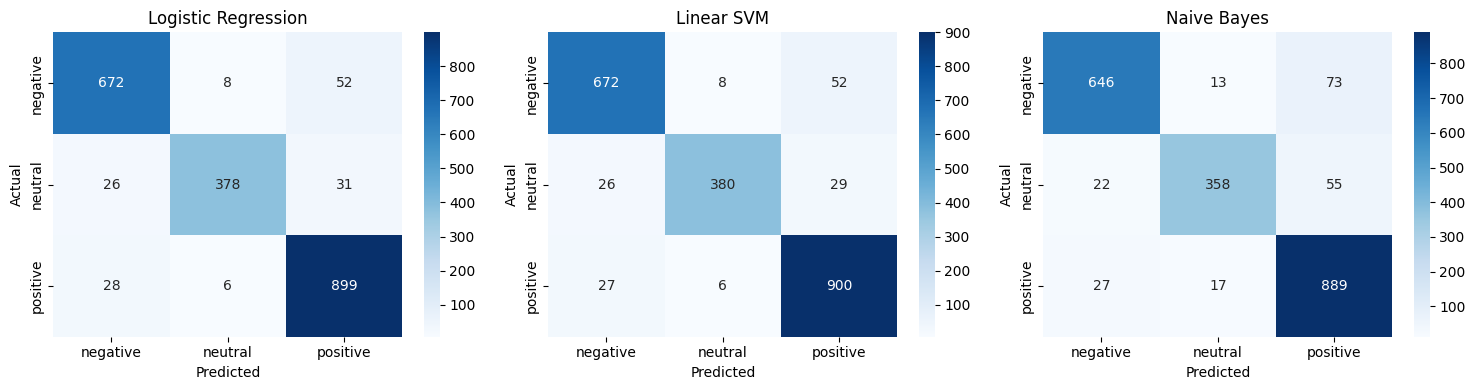

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'], labels=r['model'].classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=r['model'].classes_, yticklabels=r['model'].classes_)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 6. Classification report — best model

In [8]:
best_name = max(results, key=lambda n: results[n]['macro_f1'])
best = results[best_name]
print(f'Best model: {best_name}')
print(classification_report(y_test, best['preds']))


Best model: Linear SVM
              precision    recall  f1-score   support

    negative       0.93      0.92      0.92       732
     neutral       0.96      0.87      0.92       435
    positive       0.92      0.96      0.94       933

    accuracy                           0.93      2100
   macro avg       0.94      0.92      0.93      2100
weighted avg       0.93      0.93      0.93      2100



## 7. Most influential words per class

In [9]:
feature_names = vectorizer.get_feature_names_out()
model = best['model']

if best_name == 'Naive Bayes':
    coef_source = model.feature_log_prob_
else:
    coef_source = model.coef_

for i, cls in enumerate(model.classes_):
    row = coef_source[i] if coef_source.shape[0] > 1 else coef_source[0]
    top_idx = row.argsort()[-12:][::-1]
    print(f'{cls}: ' + ', '.join(feature_names[j] for j in top_idx))


negative: worth, disappoint, flimsi, aw, clunki, faulti, shoddi, terribl, frustrat, uncomfort, defect, slow
neutral: okay, fine, accept, decent, reason, ago deliveri, averag, ago fine, ago packag, ago doe, standard, ago featur
positive: impress, afford, comfort, superb, great, respons, smooth, fast, wonder, reliabl, solid, outstand
